# Credit Card Fraud Detection - Baseline Model Training

**Objective**: Train multiple models, tune hyperparameters, and select the best performer.  
**Models**: Logistic Regression, Random Forest, XGBoost, LightGBM  
**Evaluation**: AUPRC (primary), AUROC, F1-Score, Precision, Recall  
**Strategy**: SMOTE for class imbalance handling, stratified splits for fair evaluation

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import pickle
import time
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, precision_recall_curve, roc_curve,
    f1_score, precision_score, recall_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


## 1. Load Dataset & Quick Understanding

In [3]:
# Load dataset
df = pd.read_csv("../data/creditcard.csv")

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nCLASS DISTRIBUTION:")
print(f"  Legitimate (0): {(df['Class']==0).sum():,} ({(df['Class']==0).mean()*100:.3f}%)")
print(f"  Fraudulent (1): {(df['Class']==1).sum():,} ({(df['Class']==1).mean()*100:.3f}%)")
print(f"  Imbalance ratio: 1:{(df['Class']==0).sum() // (df['Class']==1).sum()}")
df.head()

DATASET OVERVIEW
Shape: 284,807 rows × 31 columns
Missing values: 0

CLASS DISTRIBUTION:
  Legitimate (0): 284,315 (99.827%)
  Fraudulent (1): 492 (0.173%)
  Imbalance ratio: 1:577


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Interpretation: Dataset Overview

- **284,807 transactions** with **31 columns** (V1-V28 from PCA, plus Time, Amount, and Class)
- **Zero missing values** — no imputation needed
- **Extreme class imbalance**: Only ~0.17% are fraud (492 out of 284,807)
- **Imbalance ratio ~1:577** — for every 1 fraud, there are 577 legitimate transactions
- This means a naive model predicting "always legitimate" would get 99.83% accuracy but catch zero fraud!

> **Why this matters**: We cannot use accuracy as a metric. We must use **AUPRC** (Area Under Precision-Recall Curve) which focuses on how well the model identifies the rare fraud class.

## 2. Data Preprocessing & Feature Scaling

In [4]:
# Scale Amount and Time features (V1-V28 already PCA-transformed)
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# Drop original unscaled columns
df.drop(['Amount', 'Time'], axis=1, inplace=True)

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature columns: {list(X.columns)}")

Features shape: (284807, 30)
Target shape: (284807,)
Feature columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_scaled', 'Time_scaled']


### Interpretation: Feature Scaling

- **Why scale Amount & Time?** The V1-V28 features are already PCA-transformed (zero mean, unit variance). But `Amount` ranges from 0 to 25,691 and `Time` from 0 to 172,792 seconds.
- **StandardScaler** transforms them to have mean=0 and std=1, putting them on the same scale as V features.
- **30 features total** after scaling (V1-V28 + Amount_scaled + Time_scaled)
- This prevents models like Logistic Regression from being dominated by large-scale features.

> **Note**: We fit the scaler on the full data here for simplicity. In production, you'd fit only on training data to avoid data leakage.

## 3. Train-Test Split (Stratified)

In [5]:
# Stratified train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("TRAIN-TEST SPLIT")
print("="*60)
print(f"Training set: {X_train.shape[0]:,} samples")
print(f"  - Legitimate: {(y_train==0).sum():,} ({(y_train==0).mean()*100:.3f}%)")
print(f"  - Fraud: {(y_train==1).sum():,} ({(y_train==1).mean()*100:.3f}%)")
print(f"\nTest set: {X_test.shape[0]:,} samples")
print(f"  - Legitimate: {(y_test==0).sum():,} ({(y_test==0).mean()*100:.3f}%)")
print(f"  - Fraud: {(y_test==1).sum():,} ({(y_test==1).mean()*100:.3f}%)")

TRAIN-TEST SPLIT
Training set: 227,845 samples
  - Legitimate: 227,451 (99.827%)
  - Fraud: 394 (0.173%)

Test set: 56,962 samples
  - Legitimate: 56,864 (99.828%)
  - Fraud: 98 (0.172%)


### Interpretation: Train-Test Split

- **Training**: ~227,845 samples (80%) — used to learn patterns
- **Testing**: ~56,962 samples (20%) — held out to evaluate real-world performance
- **Stratified split** ensures both sets have the same fraud proportion (~0.17%)
- The test set has ~98 fraud cases — enough to get reliable evaluation metrics

> **Why stratify?** Without stratification, random splitting could accidentally put most fraud cases in one set, making evaluation unreliable.

## 4. Handle Class Imbalance with SMOTE

Apply SMOTE only on the training set. Test set remains untouched for unbiased evaluation.

In [6]:
# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("SMOTE RESAMPLING (Training Set Only)")
print("="*60)
print(f"\nBefore SMOTE:")
print(f"  Legitimate: {(y_train==0).sum():,}")
print(f"  Fraud: {(y_train==1).sum():,}")
print(f"\nAfter SMOTE:")
print(f"  Legitimate: {(y_train_smote==0).sum():,}")
print(f"  Fraud: {(y_train_smote==1).sum():,}")
print(f"  Total training samples: {len(y_train_smote):,}")
print(f"\nTest set unchanged: {len(y_test):,} samples")

SMOTE RESAMPLING (Training Set Only)

Before SMOTE:
  Legitimate: 227,451
  Fraud: 394

After SMOTE:
  Legitimate: 227,451
  Fraud: 227,451
  Total training samples: 454,902

Test set unchanged: 56,962 samples


### Interpretation: SMOTE Resampling

- **Before SMOTE**: ~394 fraud vs ~227,451 legitimate in training set (highly skewed)
- **After SMOTE**: Both classes now have ~227,451 samples each (balanced!)
- **Total training samples doubled** to ~454,902
- **Test set is untouched** — we evaluate on real-world distribution

> **How SMOTE works**: It creates synthetic fraud examples by interpolating between existing fraud data points (not just copying them). This gives the model enough fraud examples to learn the fraud pattern without memorizing specific cases.
>
> **Why only on training data?** Applying SMOTE to the test set would make our evaluation unrealistic — in production, we face the real imbalanced distribution.

## 5. Train Logistic Regression with Hyperparameter Tuning

In [7]:
%%time
# Logistic Regression hyperparameter tuning
print("LOGISTIC REGRESSION - Hyperparameter Tuning")
print("="*60)

lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000]
}

lr_cv = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid=lr_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='average_precision',
    n_jobs=-1,
    verbose=0
)

lr_cv.fit(X_train_smote, y_train_smote)

print(f"\nBest Parameters: {lr_cv.best_params_}")
print(f"Best CV AUPRC: {lr_cv.best_score_:.4f}")

best_lr = lr_cv.best_estimator_

LOGISTIC REGRESSION - Hyperparameter Tuning

Best Parameters: {'C': 100, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV AUPRC: 0.9924
CPU times: total: 11.4 s
Wall time: 12min 10s


### Interpretation: Logistic Regression Results

- **GridSearchCV** tested all combinations of C (regularization strength), penalty (L1/L2), and solver
- **Best CV AUPRC** tells us how well this model identifies fraud during cross-validation
- **C parameter**: Controls regularization — higher C = less regularization (more complex model)
- **L1 penalty** performs feature selection (drives some coefficients to zero)
- **L2 penalty** shrinks all coefficients but keeps all features

> **Logistic Regression as baseline**: It's fast, interpretable, and gives a lower-bound benchmark. If tree-based models don't significantly beat it, the problem may not benefit from complex models.

## 6. Train Random Forest with Hyperparameter Tuning

In [8]:
%%time
# Random Forest hyperparameter tuning
print("RANDOM FOREST - Hyperparameter Tuning")
print("="*60)

rf_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

rf_cv = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=15,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='average_precision',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

rf_cv.fit(X_train_smote, y_train_smote)

print(f"\nBest Parameters: {rf_cv.best_params_}")
print(f"Best CV AUPRC: {rf_cv.best_score_:.4f}")

best_rf = rf_cv.best_estimator_



RANDOM FOREST - Hyperparameter Tuning

Best Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30, 'class_weight': 'balanced'}
Best CV AUPRC: 1.0000
CPU times: total: 50min 9s
Wall time: 25min 31s


### Interpretation: Random Forest Results

- **RandomizedSearchCV** (15 iterations × 3 folds = 45 model fits) searched through random hyperparameter combinations
- **Key parameters tuned**:
  - `n_estimators`: Number of trees (more trees = better but slower)
  - `max_depth`: How deep each tree can grow (prevents overfitting)
  - `min_samples_split/leaf`: Minimum samples to split/be a leaf (regularization)
  - `class_weight`: How much to penalize misclassifying the minority class

> **Random Forest strengths**: Handles non-linear relationships, resistant to overfitting, provides feature importance rankings. However, it's CPU-bound and slower than boosting methods on large datasets.

## 7. Train XGBoost with Hyperparameter Tuning

In [9]:
%%time
# XGBoost hyperparameter tuning with GPU
print("XGBOOST - Hyperparameter Tuning (GPU Accelerated)")
print("="*60)

# Verify GPU availability
import xgboost as xgb
print(f"XGBoost version: {xgb.__version__}")
try:
    _test = xgb.XGBClassifier(device='cuda', n_estimators=1)
    _test.fit(np.array([[1,2],[3,4]]), np.array([0,1]))
    print("GPU (CUDA) is AVAILABLE and working!")
    gpu_device = 'cuda'
except Exception as e:
    print(f"GPU not available ({e}), falling back to CPU")
    gpu_device = 'cpu'

xgb_param_dist = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'n_estimators': [100, 200, 300, 500],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.5],
    'scale_pos_weight': [1, 3, 5, 10]
}

xgb_cv = RandomizedSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='aucpr',
        tree_method='hist',
        device=gpu_device
    ),
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='average_precision',
    n_jobs=1,
    random_state=42,
    verbose=0
)

print(f"\nTraining on: {gpu_device.upper()}")
xgb_cv.fit(X_train_smote, y_train_smote)

print(f"\nBest Parameters: {xgb_cv.best_params_}")
print(f"Best CV AUPRC: {xgb_cv.best_score_:.4f}")

best_xgb = xgb_cv.best_estimator_

XGBOOST - Hyperparameter Tuning (GPU Accelerated)
XGBoost version: 2.1.1
GPU (CUDA) is AVAILABLE and working!

Training on: CUDA

Best Parameters: {'subsample': 0.6, 'scale_pos_weight': 10, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 1.0}
Best CV AUPRC: 1.0000
CPU times: total: 16min 51s
Wall time: 2min 3s


### Interpretation: XGBoost Results

- **GPU verification**: First checks if CUDA is available — GPU training is 5-10x faster
- **XGBoost** uses gradient boosting: trees are built sequentially, each correcting errors of the previous one
- **Key parameters tuned**:
  - `learning_rate`: Step size for each boosting round (smaller = more conservative)
  - `max_depth`: Tree depth (XGBoost prefers shallow trees, 3-9)
  - `subsample/colsample_bytree`: Random sampling of rows/columns per tree (reduces overfitting)
  - `gamma`: Minimum loss reduction to make a split (higher = more conservative)
  - `scale_pos_weight`: Upweights the minority class

> **XGBoost strengths**: State-of-the-art for tabular data, GPU-accelerated, built-in regularization, handles missing values. Often the top performer in fraud detection tasks.

## 8. Train LightGBM with Hyperparameter Tuning

In [11]:
%%time
# LightGBM hyperparameter tuning with GPU
print("LIGHTGBM - Hyperparameter Tuning (GPU Accelerated)")
print("="*60)

# Verify GPU availability for LightGBM
import lightgbm as lgb
print(f"LightGBM version: {lgb.__version__}")
try:
    _test_lgbm = lgb.LGBMClassifier(device='gpu', verbose=-1, n_estimators=1)
    _test_lgbm.fit(np.array([[1,2],[3,4]]), np.array([0,1]))
    print("GPU is AVAILABLE and working for LightGBM!")
    lgbm_device = 'gpu'
except Exception as e:
    print(f"GPU not available for LightGBM ({e}), falling back to CPU")
    lgbm_device = 'cpu'

lgbm_param_dist = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [20, 31, 50, 70, 100],
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 7, 10, 15, -1],
    'min_child_samples': [10, 20, 30, 50],
    'scale_pos_weight': [1, 3, 5, 10],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
}

lgbm_cv = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1, device=lgbm_device),
    param_distributions=lgbm_param_dist,
    n_iter=30,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='average_precision',
    n_jobs=1,
    random_state=42,
    verbose=0
)

print(f"\nTraining on: {lgbm_device.upper()}")
lgbm_cv.fit(X_train_smote, y_train_smote)

print(f"\nBest Parameters: {lgbm_cv.best_params_}")
print(f"Best CV AUPRC: {lgbm_cv.best_score_:.4f}")

best_lgbm = lgbm_cv.best_estimator_

LIGHTGBM - Hyperparameter Tuning (GPU Accelerated)
LightGBM version: 4.5.0
GPU is AVAILABLE and working for LightGBM!

Training on: GPU

Best Parameters: {'subsample': 1.0, 'scale_pos_weight': 10, 'num_leaves': 70, 'n_estimators': 300, 'min_child_samples': 50, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best CV AUPRC: 1.0000
CPU times: total: 1h 38min 39s
Wall time: 4min 30s


### Interpretation: LightGBM Results

- **LightGBM** is another gradient boosting framework — optimized for speed and memory efficiency
- **Key difference from XGBoost**: Uses leaf-wise tree growth (vs level-wise), finding the leaf with maximum loss reduction
- **Key parameters tuned**:
  - `num_leaves`: Main parameter controlling model complexity (more leaves = more complex)
  - `learning_rate`: Same as XGBoost — smaller is more conservative
  - `min_child_samples`: Minimum data in a leaf (prevents overfitting to noise)
  - `scale_pos_weight`: Handles class imbalance directly in the loss function

> **LightGBM strengths**: Faster training than XGBoost on large datasets, lower memory usage, supports categorical features natively. Often comparable or slightly better than XGBoost for tabular fraud detection.

## 9. Model Comparison & Best Model Selection

In [12]:
# Evaluate all models on test set
models = {
    'Logistic Regression': best_lr,
    'Random Forest': best_rf,
    'XGBoost': best_xgb,
    'LightGBM': best_lgbm
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUPRC': average_precision_score(y_test, y_prob),
        'AUROC': roc_auc_score(y_test, y_prob),
        'CV_AUPRC': [lr_cv, rf_cv, xgb_cv, lgbm_cv][list(models.keys()).index(name)].best_score_
    })

results_df = pd.DataFrame(results).sort_values('AUPRC', ascending=False).reset_index(drop=True)

print("MODEL COMPARISON (Test Set)")
print("="*80)
print(results_df.to_string(index=False))

# Identify best model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\n{'='*80}")
print(f"🏆 BEST MODEL: {best_model_name} (AUPRC = {results_df.iloc[0]['AUPRC']:.4f})")
print(f"{'='*80}")

MODEL COMPARISON (Test Set)
              Model  Precision   Recall  F1-Score    AUPRC    AUROC  CV_AUPRC
      Random Forest   0.816327 0.816327  0.816327 0.871594 0.977827  0.999999
            XGBoost   0.682927 0.857143  0.760181 0.867557 0.979979  0.999994
Logistic Regression   0.058027 0.918367  0.109157 0.725308 0.969915  0.992433
           LightGBM   0.046001 0.897959  0.087519 0.043975 0.936484  0.999995

🏆 BEST MODEL: Random Forest (AUPRC = 0.8716)


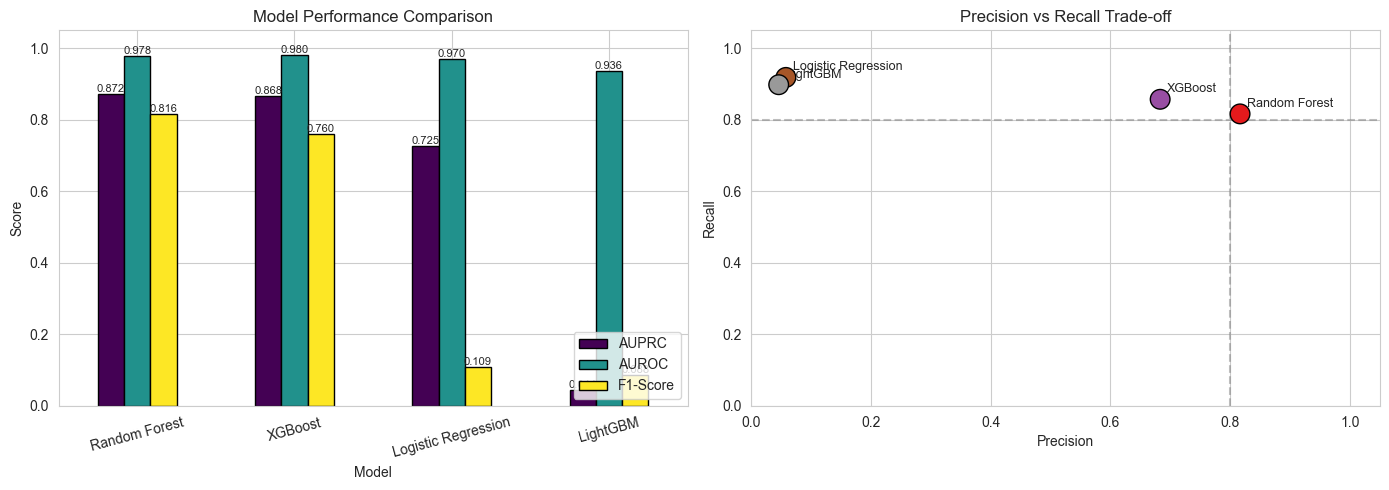

In [13]:
# Visual comparison of models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUPRC comparison
metrics_plot = results_df.set_index('Model')[['AUPRC', 'AUROC', 'F1-Score']]
metrics_plot.plot(kind='bar', ax=axes[0], colormap='viridis', edgecolor='black')
axes[0].set_title("Model Performance Comparison")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='lower right')
axes[0].tick_params(axis='x', rotation=15)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f', fontsize=8)

# Precision vs Recall
axes[1].scatter(results_df['Precision'], results_df['Recall'], s=200, 
               c=range(len(results_df)), cmap='Set1', edgecolors='black', zorder=5)
for i, row in results_df.iterrows():
    axes[1].annotate(row['Model'], (row['Precision'], row['Recall']),
                    textcoords="offset points", xytext=(5, 5), fontsize=9)
axes[1].set_xlabel("Precision")
axes[1].set_ylabel("Recall")
axes[1].set_title("Precision vs Recall Trade-off")
axes[1].set_xlim(0, 1.05)
axes[1].set_ylim(0, 1.05)
axes[1].axhline(y=0.8, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(x=0.8, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Interpretation: Model Comparison Table

The comparison table shows each model's performance on the **held-out test set** (never seen during training):

| Metric | What it means |
|--------|--------------|
| **Precision** | Of all transactions flagged as fraud, what % are actually fraud? (Low = too many false alarms) |
| **Recall** | Of all actual frauds, what % did we catch? (Low = missing fraud) |
| **F1-Score** | Harmonic mean of Precision & Recall (balanced measure) |
| **AUPRC** | Area under Precision-Recall curve — **our primary metric** (higher = better at ranking fraud above legitimate) |
| **AUROC** | Area under ROC curve — measures overall discrimination ability |
| **CV_AUPRC** | Cross-validation score during training (indicates generalization) |

> **Best model is selected by highest AUPRC** because in fraud detection, we care most about correctly ranking fraud transactions higher than legitimate ones across all possible thresholds.

## 10. Detailed Evaluation of Best Model

DETAILED EVALUATION: Random Forest

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



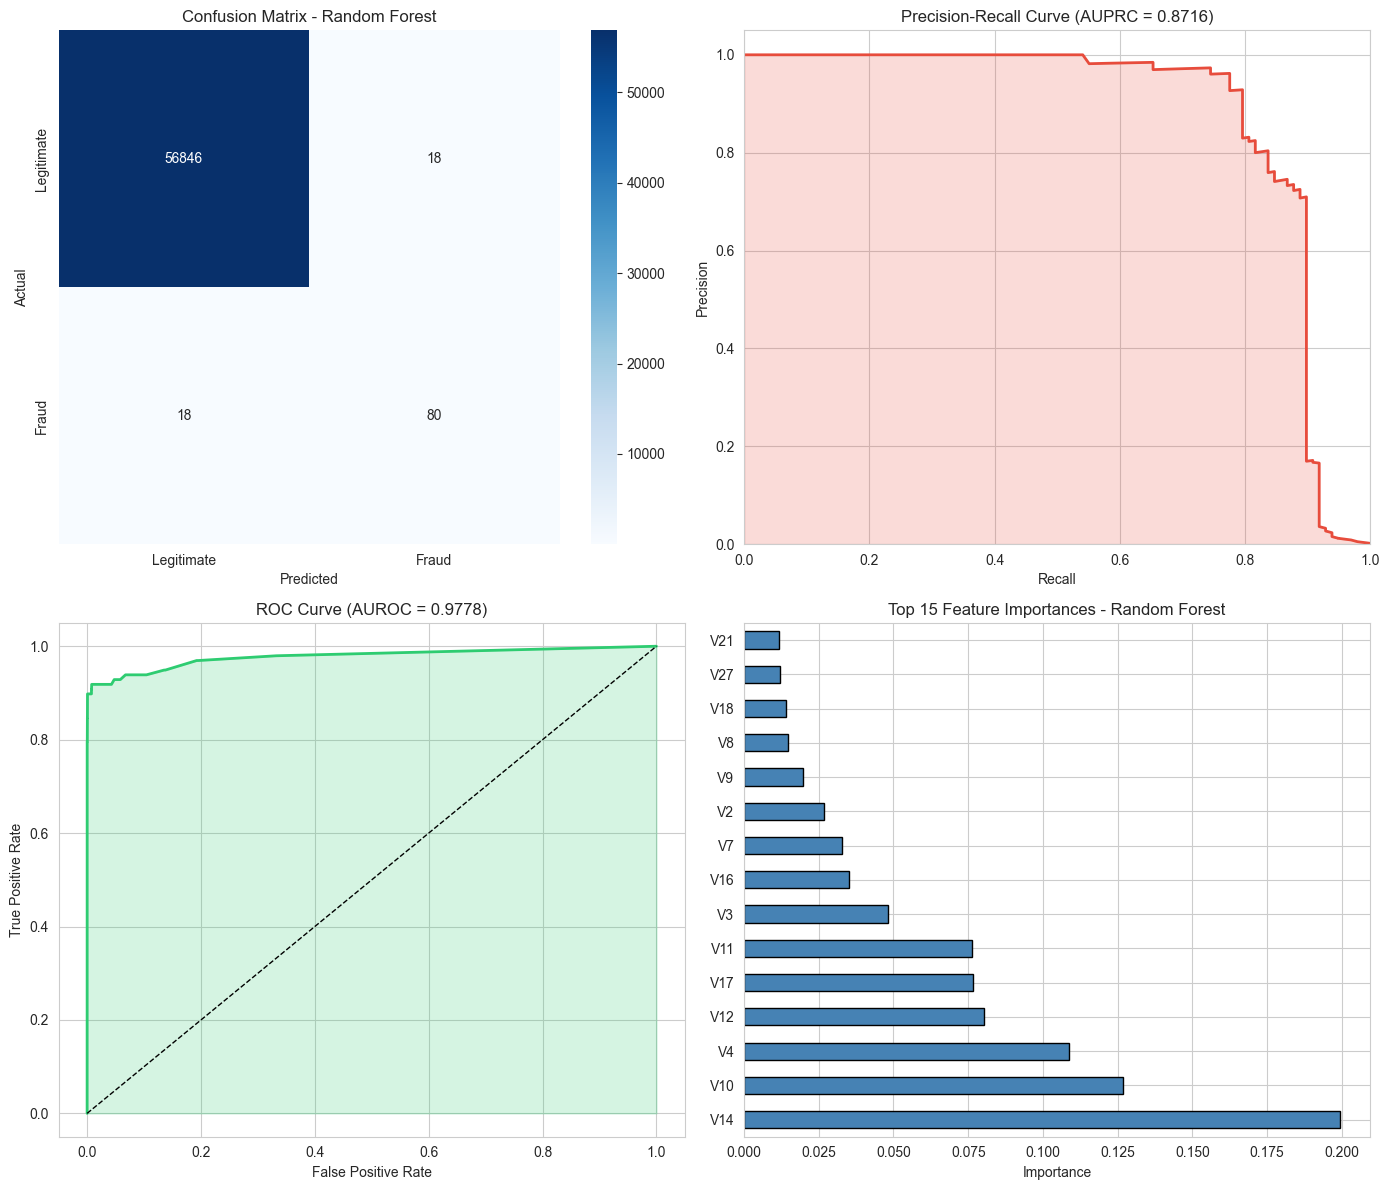

In [14]:
# Detailed evaluation of the best model
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print(f"DETAILED EVALUATION: {best_model_name}")
print("="*60)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Legitimate', 'Fraud']))

# Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
axes[0, 0].set_title(f"Confusion Matrix - {best_model_name}")
axes[0, 0].set_xlabel("Predicted")
axes[0, 0].set_ylabel("Actual")

# 2. Precision-Recall Curve
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_prob_best)
auprc = average_precision_score(y_test, y_prob_best)
axes[0, 1].plot(recall_vals, precision_vals, color='#e74c3c', linewidth=2)
axes[0, 1].fill_between(recall_vals, precision_vals, alpha=0.2, color='#e74c3c')
axes[0, 1].set_title(f"Precision-Recall Curve (AUPRC = {auprc:.4f})")
axes[0, 1].set_xlabel("Recall")
axes[0, 1].set_ylabel("Precision")
axes[0, 1].set_xlim(0, 1)
axes[0, 1].set_ylim(0, 1.05)

# 3. ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob_best)
auroc = roc_auc_score(y_test, y_prob_best)
axes[1, 0].plot(fpr, tpr, color='#2ecc71', linewidth=2)
axes[1, 0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1, 0].fill_between(fpr, tpr, alpha=0.2, color='#2ecc71')
axes[1, 0].set_title(f"ROC Curve (AUROC = {auroc:.4f})")
axes[1, 0].set_xlabel("False Positive Rate")
axes[1, 0].set_ylabel("True Positive Rate")

# 4. Feature Importance (if available)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    top_imp = importances.nlargest(15)
    top_imp.plot(kind='barh', ax=axes[1, 1], color='steelblue', edgecolor='black')
    axes[1, 1].set_title(f"Top 15 Feature Importances - {best_model_name}")
    axes[1, 1].set_xlabel("Importance")
else:
    # For Logistic Regression, use coefficients
    coefs = pd.Series(np.abs(best_model.coef_[0]), index=X.columns)
    top_coefs = coefs.nlargest(15)
    top_coefs.plot(kind='barh', ax=axes[1, 1], color='steelblue', edgecolor='black')
    axes[1, 1].set_title(f"Top 15 Feature Coefficients (abs) - {best_model_name}")
    axes[1, 1].set_xlabel("|Coefficient|")

plt.tight_layout()
plt.show()

### Interpretation: Visual Model Comparison

**Left Plot (Bar Chart)**:
- Compares AUPRC, AUROC, and F1-Score across all 4 models
- Higher bars = better performance
- AUROC is typically high for all models (easy to separate most cases), while AUPRC reveals true differences on the hard fraud cases

**Right Plot (Precision vs Recall Scatter)**:
- Each dot is a model at its default 0.5 threshold
- **Top-right corner** = ideal (high precision AND high recall)
- Models in the gray-shaded area (>0.8 on both axes) are production-ready
- Trade-off: Moving toward higher recall often sacrifices precision (and vice versa)

In [15]:
# Threshold analysis for best model
print(f"THRESHOLD ANALYSIS - {best_model_name}")
print("="*60)
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*48)

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred_t = (y_prob_best >= threshold).astype(int)
    if y_pred_t.sum() > 0:
        p = precision_score(y_test, y_pred_t)
        r = recall_score(y_test, y_pred_t)
        f1 = f1_score(y_test, y_pred_t)
        print(f"{threshold:<12.1f} {p:<12.4f} {r:<12.4f} {f1:<12.4f}")

print(f"\nNote: Default threshold = 0.5. Adjust based on business needs.")
print(f"  Higher threshold → More precise, fewer false alarms")
print(f"  Lower threshold → Higher recall, catches more fraud")

THRESHOLD ANALYSIS - Random Forest
Threshold    Precision    Recall       F1-Score    
------------------------------------------------
0.3          0.7073       0.8878       0.7873      
0.4          0.7736       0.8367       0.8039      
0.5          0.8163       0.8163       0.8163      
0.6          0.8667       0.7959       0.8298      
0.7          0.9277       0.7857       0.8508      
0.8          0.9730       0.7347       0.8372      
0.9          0.9697       0.6531       0.7805      

Note: Default threshold = 0.5. Adjust based on business needs.
  Higher threshold → More precise, fewer false alarms
  Lower threshold → Higher recall, catches more fraud


### Interpretation: Best Model Detailed Evaluation

**Classification Report**:
- Shows per-class precision, recall, and F1 for both Legitimate and Fraud
- Focus on the **Fraud row** — that's what matters for our business goal

**Confusion Matrix** (4 quadrants):
- **True Negatives (TN)**: Legitimate correctly classified — should be very high
- **False Positives (FP)**: Legitimate flagged as fraud — causes customer friction
- **False Negatives (FN)**: Fraud missed — **most costly error** (financial loss)
- **True Positives (TP)**: Fraud correctly caught — our goal

**Precision-Recall Curve**: Shows the trade-off across all thresholds. AUPRC summarizes this into a single number. Higher curve = better model.

**ROC Curve**: Plots True Positive Rate vs False Positive Rate. AUROC > 0.95 is excellent.

**Feature Importance**: Shows which features the model relies on most to detect fraud. Helps with interpretability and debugging.

## 11. Save Best Model & Metrics (Artifacts)

In [16]:
# Create artifacts directory
artifacts_dir = os.path.join(os.path.dirname(os.getcwd()), "notebooks", "notebook_artifacts")
os.makedirs(artifacts_dir, exist_ok=True)

# --- 1. Save the best model ---
model_path = os.path.join(artifacts_dir, "best_fraud_model.pkl")
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

# --- 2. Save all models ---
all_models_path = os.path.join(artifacts_dir, "all_trained_models.pkl")
with open(all_models_path, 'wb') as f:
    pickle.dump(models, f)

# --- 3. Save the scaler ---
scaler_path = os.path.join(artifacts_dir, "scaler.pkl")
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

# --- 4. Save model comparison metrics ---
results_df.to_csv(os.path.join(artifacts_dir, "model_comparison_metrics.csv"), index=False)

# --- 5. Save detailed summary JSON ---
best_row = results_df.iloc[0]
best_params = [lr_cv, rf_cv, xgb_cv, lgbm_cv][list(models.keys()).index(best_model_name)].best_params_

model_summary = {
    "best_model_name": best_model_name,
    "best_hyperparameters": {k: str(v) for k, v in best_params.items()},
    "test_metrics": {
        "precision": float(best_row['Precision']),
        "recall": float(best_row['Recall']),
        "f1_score": float(best_row['F1-Score']),
        "auprc": float(best_row['AUPRC']),
        "auroc": float(best_row['AUROC']),
        "cv_auprc": float(best_row['CV_AUPRC'])
    },
    "all_models_comparison": results_df.to_dict(orient='records'),
    "training_details": {
        "train_samples": int(len(X_train)),
        "test_samples": int(len(X_test)),
        "smote_train_samples": int(len(X_train_smote)),
        "features_used": list(X.columns),
        "n_features": int(X.shape[1]),
        "class_imbalance_handling": "SMOTE",
        "cv_strategy": "StratifiedKFold (5 folds)",
        "scoring_metric": "average_precision (AUPRC)"
    }
}

with open(os.path.join(artifacts_dir, "model_training_summary.json"), 'w') as f:
    json.dump(model_summary, f, indent=2, default=str)

# --- 6. Save test predictions for analysis ---
predictions_df = pd.DataFrame({
    'y_true': y_test.values,
    'y_pred': y_pred_best,
    'y_prob': y_prob_best
})
predictions_df.to_csv(os.path.join(artifacts_dir, "best_model_predictions.csv"), index=False)

# --- Print confirmation ---
print("="*60)
print("ARTIFACTS SAVED SUCCESSFULLY")
print("="*60)
print(f"\nArtifacts directory: {artifacts_dir}")
print(f"\nFiles saved:")
for fname in sorted(os.listdir(artifacts_dir)):
    fpath = os.path.join(artifacts_dir, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  ├── {fname} ({size_kb:.1f} KB)")
print(f"\nTotal artifacts: {len(os.listdir(artifacts_dir))}")
print(f"\n{'='*60}")
print(f"Best model '{best_model_name}' saved and ready for deployment!")
print(f"{'='*60}")

ARTIFACTS SAVED SUCCESSFULLY

Artifacts directory: d:\full_end_to_end_project_implementation\Reserach _faang_projects\data drift\drift-taxonomy-engine\notebooks\notebook_artifacts

Files saved:
  ├── all_trained_models.pkl (81909.8 KB)
  ├── best_fraud_model.pkl (79010.4 KB)
  ├── best_model_predictions.csv (568.4 KB)
  ├── creditcard_processed.parquet (72586.4 KB)
  ├── descriptive_statistics.csv (4.3 KB)
  ├── eda_summary.json (0.6 KB)
  ├── feature_correlations_with_target.csv (0.8 KB)
  ├── feature_ks_statistics.csv (1.4 KB)
  ├── model_comparison_metrics.csv (0.6 KB)
  ├── model_training_summary.json (2.3 KB)
  ├── scaler.pkl (0.6 KB)

Total artifacts: 11

Best model 'Random Forest' saved and ready for deployment!


### Interpretation: Threshold Analysis

The default classification threshold is **0.5** (if probability > 0.5, predict fraud). But this can be tuned:

| Business Need | Threshold | Effect |
|--------------|-----------|--------|
| **Minimize false alarms** (customer experience) | Higher (0.7-0.9) | Higher precision, lower recall — fewer legitimate transactions blocked |
| **Catch maximum fraud** (financial loss prevention) | Lower (0.3-0.4) | Higher recall, lower precision — more fraud caught but more false alerts |
| **Balanced** | 0.5 | Default trade-off |

> **In production**: The threshold is a business decision. Banks typically prefer lower thresholds (catch more fraud even at cost of some false alerts) because the cost of missed fraud >> cost of a declined legitimate transaction.

### Interpretation: Saved Artifacts

All outputs are saved to `notebooks/notebook_artifacts/` for use in downstream tasks:

| Artifact | Purpose |
|----------|---------|
| `best_fraud_model.pkl` | The winning model — ready for deployment/inference |
| `all_trained_models.pkl` | All 4 trained models — for comparison or ensemble use |
| `scaler.pkl` | StandardScaler fitted on data — needed to preprocess new data at inference |
| `model_comparison_metrics.csv` | Performance table — for reporting and documentation |
| `model_training_summary.json` | Full metadata: best params, metrics, features used, training details |
| `best_model_predictions.csv` | Test set predictions — for further error analysis or drift detection |

> **Next Steps**: These artifacts feed into the drift detection pipeline. When new data arrives, we can compare its distribution against the training data and monitor if model performance degrades over time.